# Q1: Which courier assignment strategy gives the fastest average delivery time?

This notebook compares the **NAC** and **SWB** courier assignment strategies. The main outcome is `click_to_door_min`, which measures the total time from when an order is placed until it is delivered.

Because delivery time also depends on fleet size, NAC and SWB are compared separately for fleets of 200 and 500 couriers.

## Imports

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
plt.style.use("seaborn-v0_8-whitegrid")

## Load the delivery-event data

In [6]:
file_name = "dc_delivery_events.csv"
data_path = Path("../data/clean") / file_name
# Load data
deliveries = pd.read_csv(data_path)
print(f"Loaded {len(deliveries):,} rows")
deliveries.head()

Loaded 60,752 rows


,order_id,strategy,fleet,hour,pickup_node,dropoff_node,drive_time_s,drive_dist_m,t_order_s,t_assign_s,t_pickup_s,t_deliver_s,click_to_door_min,courier_id
0,1,nac,200,0,49743231,646216520,1133.4,14133.0,81.8,81.8,681.8,1935.2,30.89,179
1,2,nac,200,0,774340109,49779846,349.3,3917.0,110.9,110.9,710.9,1180.2,17.82,145
2,3,nac,200,0,49793773,49839482,832.2,9764.0,149.8,149.8,749.8,1702.0,25.87,59
3,4,nac,200,0,49745240,49745636,154.5,1763.0,209.9,209.9,809.9,1084.4,14.57,113
4,5,nac,200,0,4807605970,49800282,346.0,3862.0,304.0,304.0,904.0,1370.0,17.77,66


## Check the data needed for Q1

For this question, we need four columns:

- `order_id`: identifies each order
- `strategy`: NAC or SWB
- `fleet`: number of couriers
- `click_to_door_min`: total delivery time in minutes

In [8]:
q1_columns = ["order_id", "strategy", "fleet", "click_to_door_min"]
# Check that the data has the expected columns
print("Rows and unique orders in each setting:")
design_check = (
    deliveries.groupby(["fleet", "strategy"])
    .agg(rows=("order_id", "size"), unique_orders=("order_id", "nunique"))
)
display(design_check)

Rows and unique orders in each setting:


rows  unique_orders
fleet strategy                      
200   nac       15188          15188
      swb       15188          15188
500   nac       15188          15188
      swb       15188          15188

Each fleet-strategy setting contains the same 15,188 orders. This balanced design allows a fair comparison.

## Calculate average delivery time

The mean is the main measure because the question asks for **average** delivery time. The median and standard deviation are included to describe the distribution. A 95% confidence interval is also calculated for each mean.

In [9]:
summary = (
    deliveries.groupby(["fleet", "strategy"])["click_to_door_min"]
    .agg(count="count", mean="mean", median="median", std="std")
    .reset_index()
)

summary["standard_error"] = summary["std"] / np.sqrt(summary["count"])
summary["ci_95_low"] = summary["mean"] - 1.96 * summary["standard_error"]
summary["ci_95_high"] = summary["mean"] + 1.96 * summary["standard_error"]

summary.round(2)

,fleet,strategy,count,mean,median,std,standard_error,ci_95_low,ci_95_high
0,200,nac,15188,137.96,126.42,87.18,0.71,136.57,139.35
1,200,swb,15188,129.01,118.78,81.22,0.66,127.72,130.30
2,500,nac,15188,21.59,21.05,4.90,0.04,21.51,21.67
3,500,swb,15188,22.21,21.72,4.96,0.04,22.13,22.29


## Visualize the strategy comparison

The two fleet sizes use separate panels because their delivery-time scales are very different. The error bars show 95% confidence intervals.

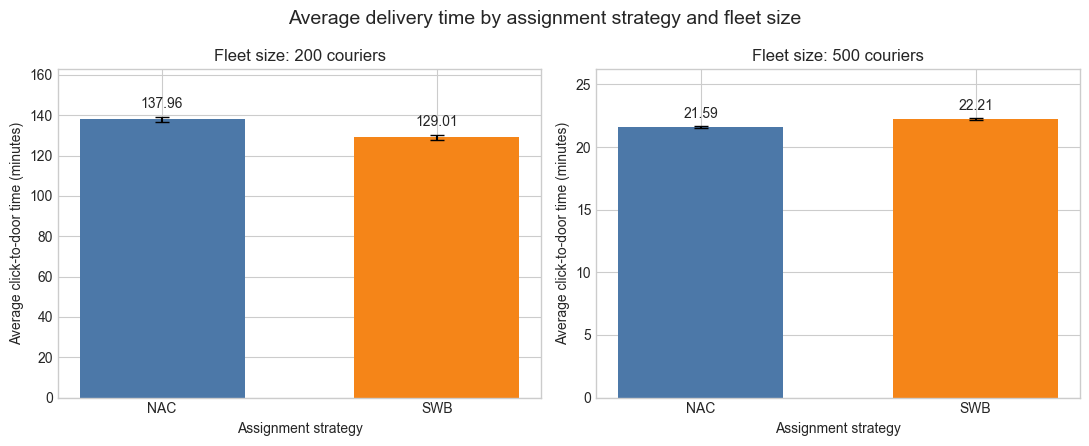

In [10]:
colors = {"nac": "#4C78A8", "swb": "#F58518"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, fleet_size in zip(axes, sorted(summary["fleet"].unique())):
    plot_data = summary[summary["fleet"] == fleet_size].copy()
    error = 1.96 * plot_data["standard_error"]

    bars = ax.bar(
        plot_data["strategy"].str.upper(),
        plot_data["mean"],
        yerr=error,
        capsize=5,
        color=[colors[value] for value in plot_data["strategy"]],
        width=0.6,
    )

    ax.set_title(f"Fleet size: {fleet_size} couriers")
    ax.set_xlabel("Assignment strategy")
    ax.set_ylabel("Average click-to-door time (minutes)")
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=10)
    ax.set_ylim(0, plot_data["mean"].max() * 1.18)

fig.suptitle("Average delivery time by assignment strategy and fleet size", fontsize=14)
fig.tight_layout()
plt.show()

## Compare the same orders with a paired test

The same order was simulated under both strategies. Therefore, a paired t-test is more appropriate than an independent t-test.

The difference is calculated as:

$$	ext{difference} = 	ext{SWB time} - 	ext{NAC time}$$

A negative difference means SWB is faster. A positive difference means NAC is faster.

In [11]:
paired_results = []

for fleet_size in sorted(deliveries["fleet"].unique()):
    paired = (
        deliveries[deliveries["fleet"] == fleet_size]
        .pivot(index="order_id", columns="strategy", values="click_to_door_min")
        .dropna()
    )

    differences = paired["swb"] - paired["nac"]
    t_statistic, p_value = stats.ttest_rel(paired["swb"], paired["nac"])
    ci_low, ci_high = stats.t.interval(
        0.95,
        len(differences) - 1,
        loc=differences.mean(),
        scale=stats.sem(differences),
    )

    paired_results.append({
        "fleet": fleet_size,
        "nac_mean_min": paired["nac"].mean(),
        "swb_mean_min": paired["swb"].mean(),
        "swb_minus_nac_min": differences.mean(),
        "percent_change_swb_vs_nac": 100 * differences.mean() / paired["nac"].mean(),
        "difference_ci_95_low": ci_low,
        "difference_ci_95_high": ci_high,
        "t_statistic": t_statistic,
        "p_value": p_value,
    })

paired_results = pd.DataFrame(paired_results)
paired_results.round(3)

,fleet,nac_mean_min,swb_mean_min,swb_minus_nac_min,percent_change_swb_vs_nac,difference_ci_95_low,difference_ci_95_high,t_statistic,p_value
0,200,137.960,129.011,-8.949,-6.487,-9.059,-8.839,-159.437,0.0
1,500,21.591,22.208,0.617,2.860,0.589,0.646,42.096,0.0


## Overall average

The overall average is shown because the question asks which strategy is fastest. However, it should not replace the fleet-specific comparison.

In [12]:
overall = (
    deliveries.groupby("strategy")["click_to_door_min"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean")
)
overall.round(2)

,count,mean,median,std
strategy,,,,
swb,30376,75.61,28.29,78.50
nac,30376,79.78,27.56,84.84


## 8. Conclusion

**SWB has the fastest overall average delivery time: 75.61 minutes, compared with 79.78 minutes for NAC. This makes SWB about 4.17 minutes faster overall.**

However, the best strategy depends on fleet size:

- With **200 couriers**, SWB averages **129.01 minutes**, while NAC averages **137.96 minutes**. SWB is **8.95 minutes faster**, a **6.49% reduction**.
- With **500 couriers**, NAC averages **21.59 minutes**, while SWB averages **22.21 minutes**. NAC is **0.62 minutes faster**.
- Both paired differences are statistically significant ($p < 0.001$).

Therefore, **SWB is the best overall strategy and works especially well when couriers are limited, but NAC is slightly faster when 500 couriers are available.**